# Depth-First Search (DFS)

## 1. Introduction

**Depth-First Search (DFS)** is an uninformed search algorithm that explores one branch as deeply as possible before backtracking to explore alternatives.

DFS uses a **Stack (LIFO — Last In, First Out)**. Unlike BFS, DFS does **not** guarantee the shortest path in an unweighted graph.

### Key Properties

- **Type:** Uninformed Search
- **Strategy:** Explore deeply, then backtrack
- **Data Structure:** Stack (LIFO)
- **Complete:** Yes for finite graphs when repeated states are skipped; not generally complete for infinite graphs
- **Optimal:** No — the first path found may not be the shortest

### Learning Objectives

1. Understand how DFS explores a graph.
2. Explain the difference between FIFO and LIFO.
3. Implement iterative DFS in Python.
4. Trace `stack`, `path`, `node`, and `visited`.
5. Practice predicting the output and filling in missing code.

## 2. Graph Representation

A **graph** contains vertices (nodes) connected by edges. We represent a directed graph using a Python **Adjacency List**: each key stores the outgoing neighbors of a node.

We will reuse the **same graph** from our BFS notebook, so comparing both algorithms is easy.

**Search Problem:** Find a path from `S` (start) to `G` (goal). Unlike BFS, DFS is not guaranteed to choose the path with the fewest edges.

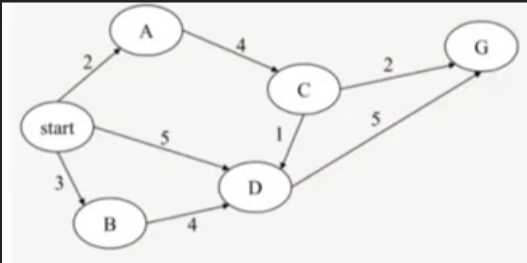

In [2]:
graph = {
    'S': ['B', 'D', 'A'],
    'A': ['C'],
    'B': ['D'],
    'C': ['G', 'D'],
    'D': ['G'],
    'G': []
}

### Understanding the Adjacency List

```python
'S': ['B', 'D', 'A']
```

This means `S` has outgoing edges to `B`, `D`, and `A` **in that listed order**.

```python
'G': []
```

This means `G` has no outgoing edges.

### Neighbor Order Matters

Our iterative DFS uses a **stack**. To visit neighbors in the order listed in the adjacency list (`B`, then `D`, then `A`), we **push them in reverse order** (`A`, then `D`, then `B`). The last item pushed will be popped first.

This changes the path DFS finds, even though it does not change whether the goal is reachable.

## 3. How DFS Works

DFS explores a single branch deeply before returning to other possible branches.

### Algorithm Steps

1. Create a stack containing a path with the starting node.
2. Remove the last path from the stack (**LIFO**).
3. Get its last node using `path[-1]`.
4. If the node has already been visited, skip this path.
5. Otherwise, mark the node as visited.
6. If the node is the goal, return the current path.
7. Push new paths for neighbors in **reverse order** so they are visited in the order listed in the graph.
8. Continue until a goal is found or the stack becomes empty.

### Why `stack` and `visited`?

- `stack.pop()` removes the **last** item: `O(1)` for Python lists.
- `visited` is a set of nodes that have been **expanded**; it prevents repeated expansion in graphs with cycles.
- Marking nodes visited **when popped** allows the first path reached in depth-first order to determine the result.
- A node can appear more than once in the stack; later duplicate paths are skipped when popped.

> **Implementation note:** We use a regular Python `list` as our stack. There is no need to import an extra data structure.

In [3]:
def dfs(graph: dict, start, goal) -> list | None:
    if start == goal:
        return [start]

    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            continue

        visited.add(node)

        if node == goal:
            return path

        for neighbor in reversed(graph.get(node, [])):
            if neighbor not in visited:
                stack.append(path + [neighbor])

    return None

## 4. Running DFS

Run DFS on the graph from `S` to `G`.

Because DFS follows the first branch as far as it can, it will discover `S → B → D → G` with this adjacency-list order.

**Expected Result:** `S → B → D → G` (3 edges).

By comparison, BFS finds `S → D → G` (2 edges). This example shows why **DFS is not optimal** for shortest paths.

In [4]:
path = dfs(graph, 'S', 'G')

print("DFS Path:", " -> ".join(path) if path else "Not Found")
print("Path Length:", len(path) - 1 if path else "N/A")

DFS Path: S -> B -> D -> G
Path Length: 3


## 5. Step-by-Step Execution

Let's trace DFS from `S` to `G` using the **same variable names** as our implementation.

The rightmost path in `stack` is popped next. The table shows `stack` **after expansion**, and `visited` **after the current node has been marked**.

| Step | `node` | `path` | `stack` (After Expansion) | `visited` |
|---|---|---|---|---|
| Initial | `—` | `—` | `[['S']]` | `{}` |
| 1 | `'S'` | `['S']` | `[['S','A'], ['S','D'], ['S','B']]` | `{'S'}` |
| 2 | `'B'` | `['S','B']` | `[['S','A'], ['S','D'], ['S','B','D']]` | `{'S','B'}` |
| 3 | `'D'` | `['S','B','D']` | `[['S','A'], ['S','D'], ['S','B','D','G']]` | `{'S','B','D'}` |
| 4 | `'G'` | `['S','B','D','G']` | **Goal found** | `{'S','B','D','G'}` |

<br>

> **Note:** Python sets are unordered; `visited` is displayed in discovery order only for readability. Once `G` is popped, the function returns immediately without expanding its neighbors.

### Observations

- **Step 1:** DFS pops `S` and pushes paths to `A`, `D`, then `B` (reverse order); `B` is on top.
- **Step 2:** DFS pops `B` and pushes `['S','B','D']` even though another path to `D` is waiting in the stack. `D` is **not yet visited**.
- **Step 3:** DFS pops `D`, marks it visited, and pushes its path to `G`.
- **Step 4:** DFS pops `G` and returns `path`.

### Final Result

**Returned `path`:** `['S', 'B', 'D', 'G']`

**Number of Edges:** `len(path) - 1 = 3`

### Understanding the Variables

- **`stack`:** Paths waiting to be explored (LIFO).
- **`visited`:** Nodes already popped and expanded (or identified as the goal).
- **`path`:** The current path popped from the stack.
- **`node`:** The last element of `path`, obtained using `path[-1]`.
- **`neighbor`:** An outgoing neighbor of the current node.

### Discovered vs. Expanded Nodes

- **Added to stack:** A path waiting to be processed; its last node is not necessarily visited yet.
- **Expanded:** A path is popped, and its node is marked visited before examining neighbors.
- The same node may be present in multiple paths in `stack`, but **only the first popped occurrence is expanded**.

In [5]:
# Not import function, but for tracing the DFS process
def dfs_trace(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            print(f"Skipping visited node: {node}")
            continue

        visited.add(node)
        print(f"Current Node: {node}")
        print(f"Current Path: {path}")

        if node == goal:
            print("Goal Found!")
            return path

        for neighbor in reversed(graph.get(node, [])):
            if neighbor not in visited:
                stack.append(path + [neighbor])

        print(f"Stack: {stack}")
        print(f"Visited: {visited}")
        print("-" * 40)

    return None


dfs_trace(graph, 'S', 'G')

Current Node: S
Current Path: ['S']
Stack: [['S', 'A'], ['S', 'D'], ['S', 'B']]
Visited: {'S'}
----------------------------------------
Current Node: B
Current Path: ['S', 'B']
Stack: [['S', 'A'], ['S', 'D'], ['S', 'B', 'D']]
Visited: {'S', 'B'}
----------------------------------------
Current Node: D
Current Path: ['S', 'B', 'D']
Stack: [['S', 'A'], ['S', 'D'], ['S', 'B', 'D', 'G']]
Visited: {'D', 'S', 'B'}
----------------------------------------
Current Node: G
Current Path: ['S', 'B', 'D', 'G']
Goal Found!


['S', 'B', 'D', 'G']

## 6. Complexity Analysis

For **standard DFS traversal**, using adjacency lists and a visited set:

- **Time:** `O(V + E)` — vertices and edges are processed at most a constant number of times in the usual implementation.
- **Space:** `O(V)` for a node-based iterative stack or visited set (excluding input graph).

Where `V` is the number of reachable vertices and `E` is the number of outgoing edges examined.

### Our Path-Based Implementation

```python
stack.append(path + [neighbor])
```

Each `path + [neighbor]` copies a list. Also, multiple pending paths may end at the same node before it has been visited. So this educational implementation has **additional time and memory overhead** compared with standard node-based DFS.

For a finite graph with `V` reachable nodes and `E` examined edges, a conservative bound is **`O(E × V + V)` time and `O(E × V + V)` auxiliary space**, accounting for stored path copies. These bounds are not necessarily tight for every graph.

### BFS vs. DFS

| Property | BFS | DFS |
|---|---|---|
| Frontier | Queue (FIFO) | Stack (LIFO) |
| Exploration | Level by level | Deep branch first |
| Shortest path in unweighted graph | Yes | Not guaranteed |
| Typical node-based traversal time | `O(V + E)` | `O(V + E)` |

**Challenge:** Can you replace path storage with parent tracking or build a recursive DFS? How would the behavior differ?

# QUIZ - Time

> TO Check your Understanding

## 1. Predict the Output

Consider our original graph:

```python
graph = {
    'S': ['B', 'D', 'A'],
    'A': ['C'],
    'B': ['D'],
    'C': ['G', 'D'],
    'D': ['G'],
    'G': []
}
```

**Question 1:** What does `dfs(graph, 'S', 'G')` return?

**Question 2:** What does `dfs(graph, 'S', 'C')` return?

**Question 3:** What does `dfs(graph, 'G', 'S')` return?

**Question 4 (Think):** If you remove `reversed()` from the DFS function, does it explore `B` or `A` first?

Predict the answers before running the next cell.

In [ ]:
test_cases = [
    ('S', 'G'),
    ('S', 'C'),
    ('G', 'S')
]

for start, goal in test_cases:
    result = dfs(graph, start, goal)
    print(f"dfs(graph, '{start}', '{goal}') = {result}")

print("Without reversed(), A would be explored before B.")

## 2. Coding Challenge — Fill in the Missing Code

Complete the missing parts of the DFS implementation.

Your task is to implement DFS using:

- A **LIFO stack** made from a Python list.
- A set of visited nodes.
- Path tracking and goal checking.
- `reversed()` to preserve the adjacency-list visit order.

### Rules

1. Replace every `____` marked `# type: ignore , TODO` with the correct Python expression or method name.
2. Do not change the function name or parameters.
3. Do not copy the complete implementation above.
4. Run the automated tests after filling in all blanks.

**Goal:** Make all tests pass. Different DFS neighbor orders may produce valid paths, but these tests deliberately check the neighbor order taught in this notebook.

In [ ]:
def dfs_challenge(graph: dict, start, goal) -> list | None:
    if start == goal:
        return ____  # type: ignore , TODO

    stack = [[start]]
    visited = ____  # type: ignore , TODO

    while ____:  # type: ignore , TODO
        path = stack.____()  # type: ignore , TODO
        node = path[____]  # type: ignore , TODO

        if node in visited:
            ____  # type: ignore , TODO

        visited.____(node)  # type: ignore , TODO

        if node == ____:  # type: ignore , TODO
            return ____  # type: ignore , TODO

        for neighbor in reversed(graph.get(node, [])):
            if neighbor not in visited:
                stack.____(path + [neighbor])  # type: ignore , TODO

    return ____  # type: ignore , TODO

In [ ]:
test_cases = [
    ("S to G", graph, 'S', 'G', ['S', 'B', 'D', 'G']),
    ("S to C", graph, 'S', 'C', ['S', 'A', 'C']),
    ("S to S", graph, 'S', 'S', ['S']),
    ("G to S", graph, 'G', 'S', None),
    ("Unknown goal", graph, 'S', 'X', None),
    ("Cycle handling", {'A': ['B'], 'B': ['A', 'C'], 'C': []}, 'A', 'C', ['A', 'B', 'C']),
]

passed = 0

for name, test_graph, start, goal, expected in test_cases:
    try:
        result = dfs_challenge(test_graph, start, goal)
        success = result == expected
        if success:
            passed += 1

        print(f"{'PASS' if success else 'FAIL'} | {name}")
        if not success:
            print(f"   Expected: {expected}")
            print(f"   Received: {result}")

    except Exception as error:
        print(f"ERROR | {name}: {type(error).__name__}: {error}")

print(f"\nFinal Score: {passed}/{len(test_cases)}")